In [27]:
import os, pickle, torch, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import lightning.pytorch as pl
from sklearn.preprocessing import RobustScaler, StandardScaler
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
warnings.filterwarnings("ignore")

In [28]:
# ============================================================
# 1. KAYITLI VERİLERİ YÜKLE
# ============================================================
save_dir = "saved_models"

# Maliyet parametreleri
with open(os.path.join(save_dir, "cost_params.pkl"), "rb") as f:
    cost = pickle.load(f)

# Dataset parametreleri
with open(os.path.join(save_dir, "dataset_params.pkl"), "rb") as f:
    dataset_params = pickle.load(f)

# Feature dataframe
df_feat = pd.read_parquet(os.path.join(save_dir, "df_feat_sim.parquet"))

print("Maliyet parametreleri:")
for k, v in cost.items():
    print(f"  {k}: {v}")
print(f"\ndf_feat shape: {df_feat.shape}")
print(f"İlçe sayısı : {df_feat['IlceKodu'].nunique()}")
print(f"Tarih aralığı: {df_feat['OrderDay'].min().date()} → {df_feat['OrderDay'].max().date()}")

Maliyet parametreleri:
  maaliyet_tl_tup: 602.515804
  tupras_tl_tup: 545.8
  tavan_fiyat: 1260.0
  tavan_ipr: 1220.0
  kdv_oran: 10

df_feat shape: (21736, 18)
İlçe sayısı : 19
Tarih aralığı: 2023-01-02 → 2026-02-18


In [29]:
# ============================================================
# 2. SCALERS + REFERENCE DATASET OLUŞTUR
# ============================================================
robust_cols = ["xfark", "x_tavanfark", "xipr", "xipr_tavan", "temp_c", "unit_price_change_day"]
standard_cols = ["month_sin", "month_cos", "day_sin", "day_cos", "is_price_fresh", "kdv_oran"]

scalers = {col: RobustScaler() for col in robust_cols}
scalers.update({col: StandardScaler() for col in standard_cols})

# Train dataset'i yeniden oluştur (encoder/scaler fit için)
total_days = df_feat["time_idx"].max()
test_days = 28
test_start = total_days - test_days

df_train = df_feat[df_feat["time_idx"] <= (test_start - 15)]  # Son fold'un train sonu

tr_dataset = TimeSeriesDataSet(
    df_train,
    time_idx="time_idx",
    target="total_quantity",
    group_ids=["IlceKodu"],
    max_encoder_length=90,
    max_prediction_length=14,
    static_categoricals=["IlceKodu", "IlKodu"],
    time_varying_known_reals=[
        "xfark", "x_tavanfark", "xipr", "xipr_tavan",
        "unit_price_change_day", "is_price_fresh",
        "temp_c", "month_sin", "month_cos",
        "day_sin", "day_cos", "kdv_oran",
    ],
    time_varying_known_categoricals=["condition_group"],
    time_varying_unknown_reals=["total_quantity"],
    target_normalizer=GroupNormalizer(groups=["IlceKodu"], transformation="softplus"),
    scalers=scalers,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

print(f"Reference dataset oluşturuldu: {len(tr_dataset)} sample")

Reference dataset oluşturuldu: 18962 sample


In [30]:
# ============================================================
# 3. MODELİ YÜKLE
# ============================================================
ckpt = torch.load(os.path.join(save_dir, "best_tft_model.ckpt"), weights_only=False)

model = TemporalFusionTransformer.from_dataset(tr_dataset, **ckpt["hparams"])
model.load_state_dict(ckpt["state_dict"])
model.eval()

print("Model yüklendi ✓")

Model yüklendi ✓


In [31]:
# ============================================================
# 4. SİMÜLASYON FONKSİYONU
# ============================================================
maaliyet = cost["maaliyet_tl_tup"]
tupras   = cost["tupras_tl_tup"]
tavan_ayg = cost["tavan_fiyat"]
tavan_ipr = cost["tavan_ipr"]
kdv      = cost["kdv_oran"]

def simulasyon(aygaz_fiyat, ipr_fiyat, ilce_kodu=None):
    """
    Verilen Aygaz ve İpragaz fiyatlarıyla 14 günlük tahmin yapar.
    
    - unit_price_change_day: [0, 1, 2, 3, 4, 5, 6, 7, 0, 0, 0, 0, 0, 0]
    - is_price_fresh:        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
    
    Parameters:
        aygaz_fiyat: Aygaz satış fiyatı (TL/tüp, KDV dahil)
        ipr_fiyat:   İpragaz satış fiyatı (TL/tüp, KDV dahil)  
        ilce_kodu:   Belirli bir ilçe (None = tüm ilçeler)
    """
    # Fiyat → x dönüşümleri
    x_new       = (aygaz_fiyat - maaliyet) / tupras
    xipr_new    = (ipr_fiyat   - maaliyet) / tupras
    x_tavan_new = (tavan_ayg   - maaliyet) / tupras
    xipr_tavan_new = (tavan_ipr - maaliyet) / tupras
    
    xfark_new       = x_new - xipr_new
    x_tavanfark_new = x_tavan_new - xipr_tavan_new
    
    # 14 günlük unit_price_change_day ve is_price_fresh
    change_day_14 = [0, 1, 2, 3, 4, 5, 6, 7, 0, 0, 0, 0, 0, 0]
    is_fresh_14   = [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
    
    # Simülasyon dataframe'i hazırla
    sim_df = df_feat.copy()
    
    if ilce_kodu is not None:
        sim_df = sim_df[sim_df["IlceKodu"] == str(ilce_kodu)]
    
    # Decoder bölgesini belirle (son 14 gün)
    max_time = sim_df["time_idx"].max()
    decoder_start = max_time - 13  # son 14 gün
    decoder_mask = sim_df["time_idx"] >= decoder_start
    
    # Fiyat featurelerini güncelle
    sim_df.loc[decoder_mask, "xfark"]       = xfark_new
    sim_df.loc[decoder_mask, "x_tavanfark"] = x_tavanfark_new
    sim_df.loc[decoder_mask, "xipr"]        = xipr_new
    sim_df.loc[decoder_mask, "xipr_tavan"]  = xipr_tavan_new
    
    # unit_price_change_day ve is_price_fresh güncelle (her ilçe için)
    for ilce in sim_df["IlceKodu"].unique():
        ilce_mask = (sim_df["IlceKodu"] == ilce) & decoder_mask
        ilce_indices = sim_df.loc[ilce_mask].index
        n = min(14, len(ilce_indices))
        for day_i in range(n):
            sim_df.loc[ilce_indices[day_i], "unit_price_change_day"] = float(change_day_14[day_i])
            sim_df.loc[ilce_indices[day_i], "is_price_fresh"]        = float(is_fresh_14[day_i])
    
    # Prediction dataset
    sim_dataset = TimeSeriesDataSet.from_dataset(
        tr_dataset,
        sim_df,
        predict=True,
        stop_randomization=True,
    )
    sim_loader = sim_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)
    
    # Tahmin
    predictions = model.predict(
        sim_loader, return_y=True, return_x=True,
        trainer_kwargs=dict(accelerator="auto"),
    )
    
    act = predictions.y[0].cpu().numpy()
    prd = predictions.output.cpu().numpy()
    groups = predictions.x["groups"].cpu().numpy()
    
    return act, prd, groups, sim_df

print("Simülasyon fonksiyonu hazır ✓")
print(f"\nMevcut fiyatlar:")
print(f"  Aygaz tavan : {tavan_ayg:.2f} ₺")
print(f"  İpragaz tavan: {tavan_ipr:.2f} ₺")
print(f"  Maliyet     : {maaliyet:.2f} ₺")

Simülasyon fonksiyonu hazır ✓

Mevcut fiyatlar:
  Aygaz tavan : 1260.00 ₺
  İpragaz tavan: 1220.00 ₺
  Maliyet     : 602.52 ₺


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Simülasyon Sonucu — Aygaz: 1150 ₺ | İpragaz: 1100 ₺
  WAPE: %23.8 | MAE: 15.2
  Toplam 14 gün tahmin: 13839 adet
  Günlük ortalama    : 52.0 adet


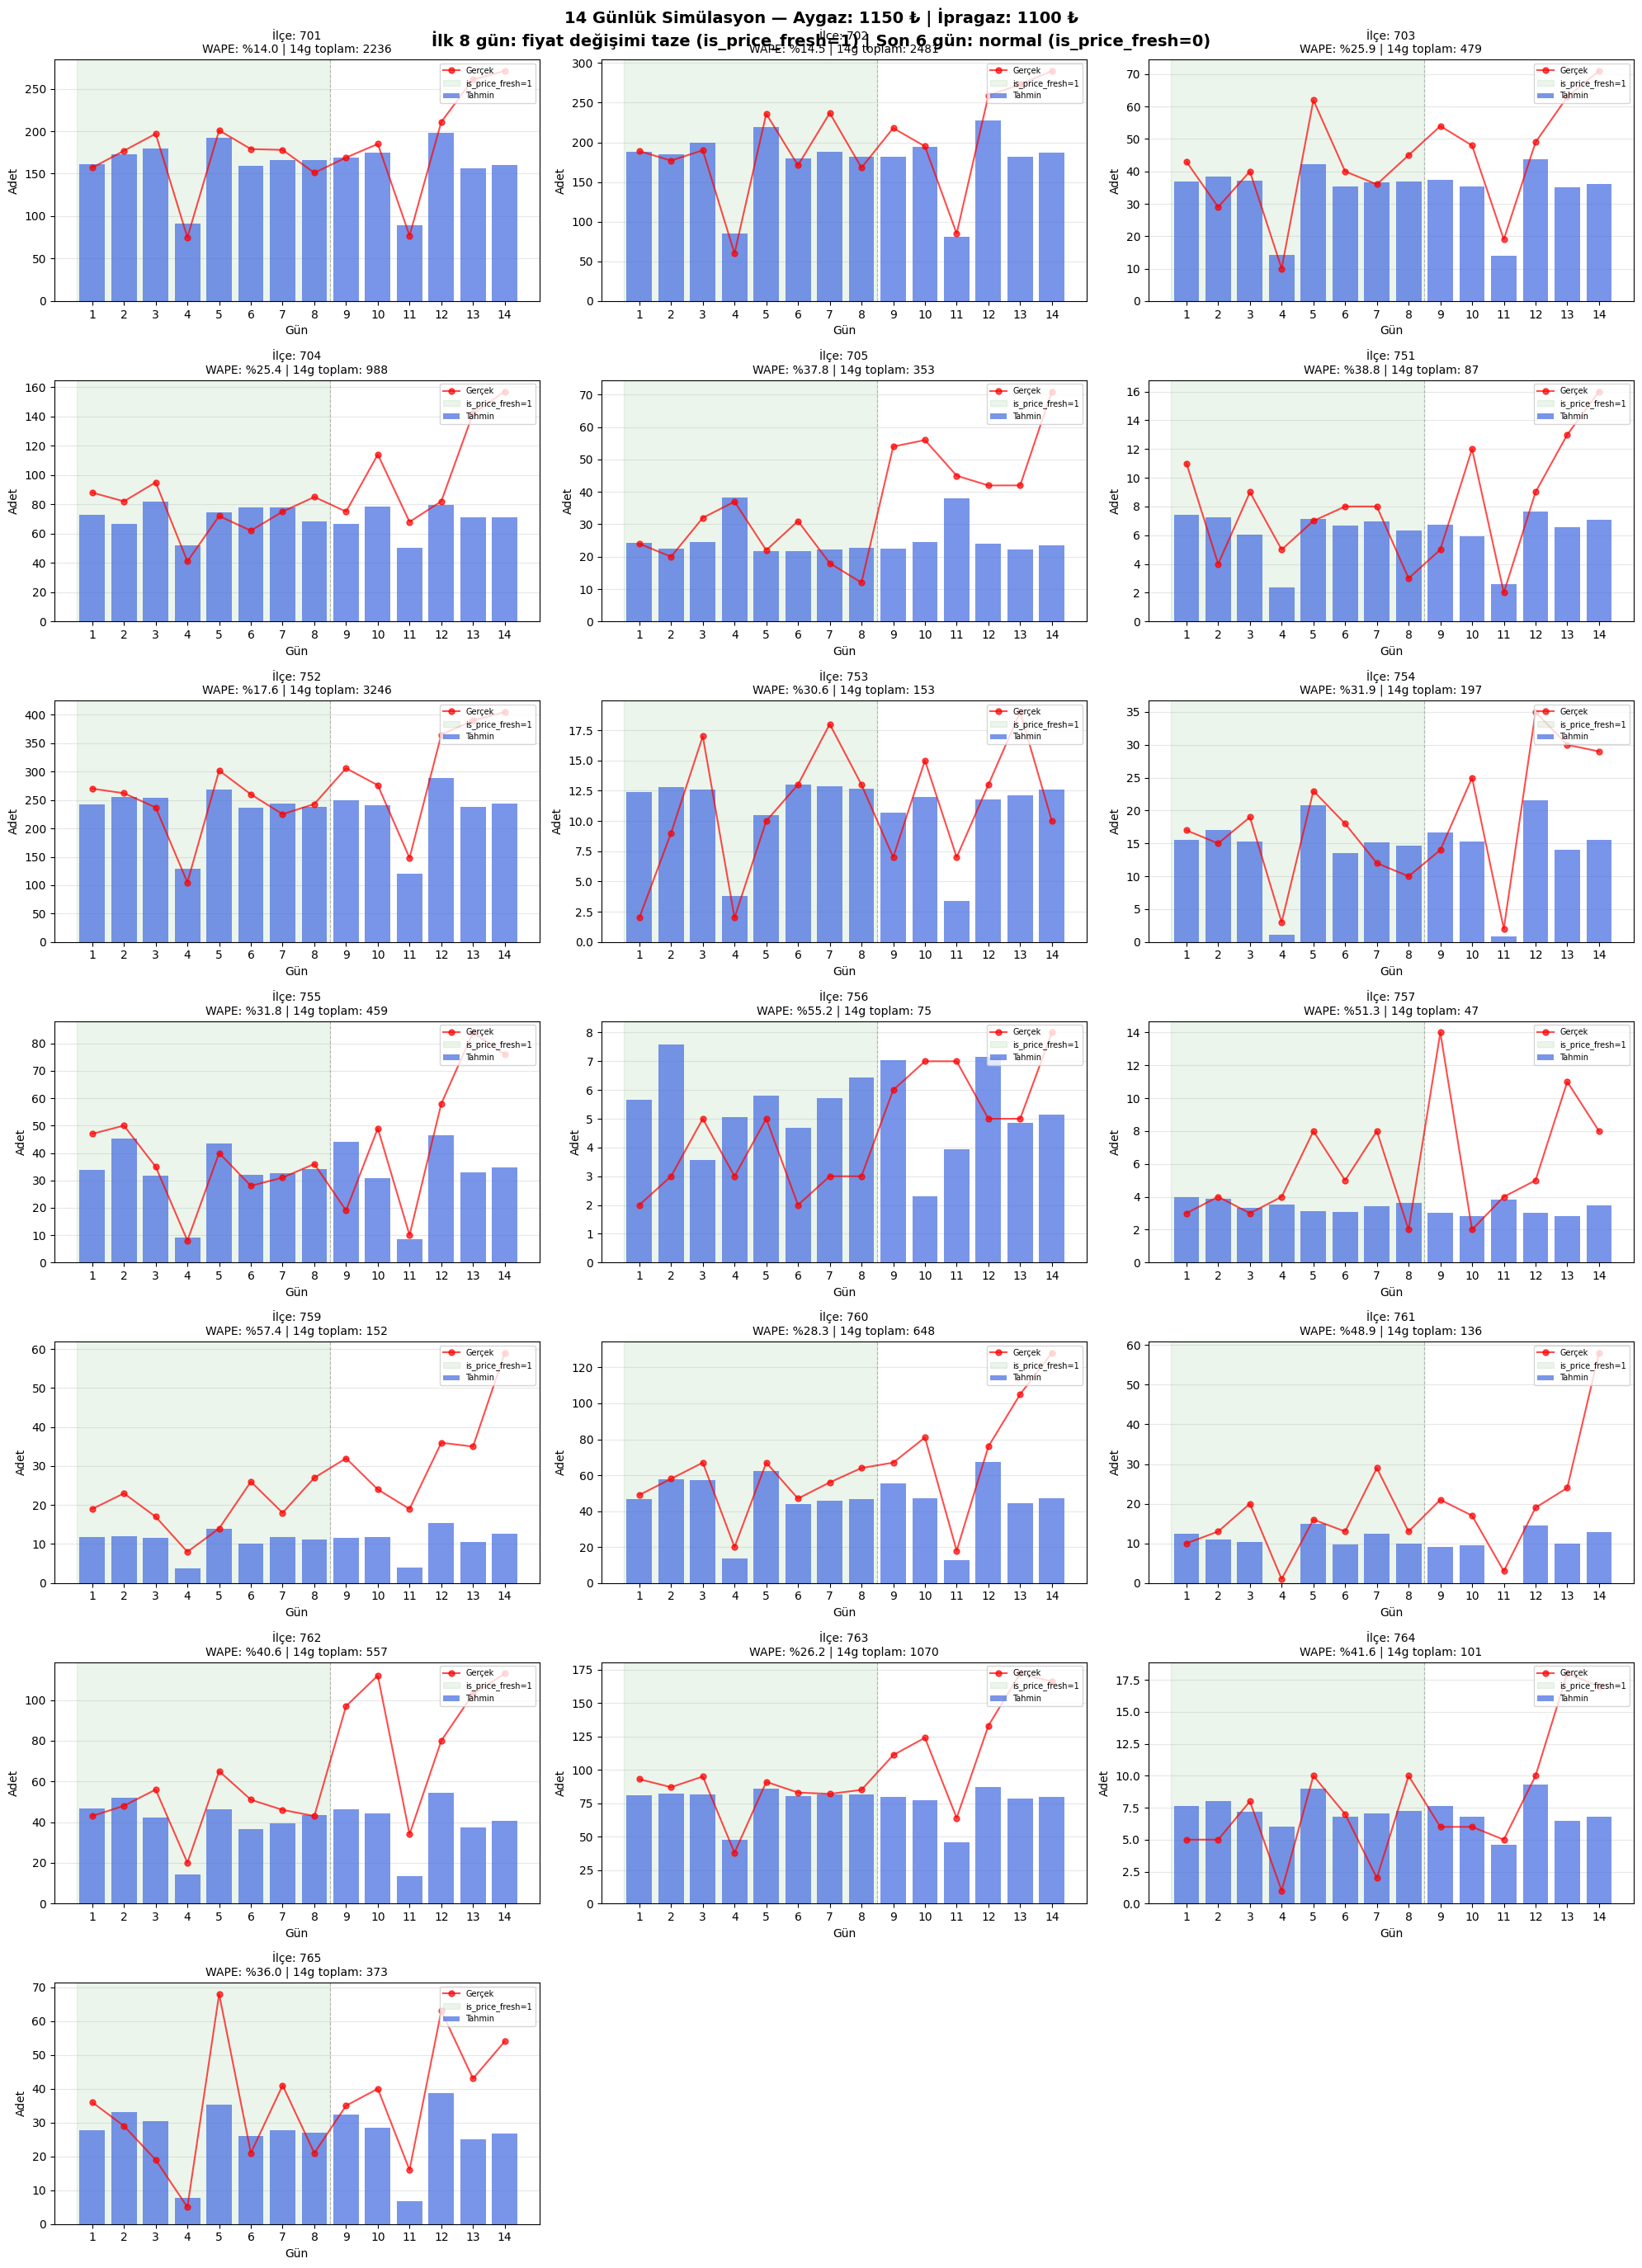


İlçe           14g Toplam   Günlük Ort     WAPE
------------------------------------------------
701                  2236        159.7 %   14.0
702                  2481        177.2 %   14.5
703                   479         34.2 %   25.9
704                   988         70.6 %   25.4
705                   353         25.2 %   37.8
751                    87          6.2 %   38.8
752                  3246        231.9 %   17.6
753                   153         10.9 %   30.6
754                   197         14.1 %   31.9
755                   459         32.8 %   31.8
756                    75          5.4 %   55.2
757                    47          3.4 %   51.3
759                   152         10.9 %   57.4
760                   648         46.3 %   28.3
761                   136          9.7 %   48.9
762                   557         39.8 %   40.6
763                  1070         76.4 %   26.2
764                   101          7.2 %   41.6
765                   373         26.6

In [26]:
# ============================================================
# 5. SİMÜLASYON ÇALIŞTIR + GRAFİK
# ============================================================

# ── KULLANICI GİRDİLERİ ──
AYGAZ_FIYAT = 1150.0   # ← Kendi fiyatınızı buraya yazın (TL/tüp)
IPRAGAZ_FIYAT = 1100.0  # ← İpragaz fiyatını buraya yazın (TL/tüp)

# ── Simülasyon çalıştır ──
act, prd, groups, sim_df = simulasyon(AYGAZ_FIYAT, IPRAGAZ_FIYAT)

ilce_ids = tr_dataset.decoded_index["IlceKodu"].unique()
unique_groups = np.unique(groups[:, 0])

# ── Genel metrikler ──
wape = np.sum(np.abs(act - prd)) / np.clip(np.sum(np.abs(act)), 1e-3, None) * 100
mae  = np.mean(np.abs(act - prd))
print(f"Simülasyon Sonucu — Aygaz: {AYGAZ_FIYAT:.0f} ₺ | İpragaz: {IPRAGAZ_FIYAT:.0f} ₺")
print(f"  WAPE: %{wape:.1f} | MAE: {mae:.1f}")
print(f"  Toplam 14 gün tahmin: {prd.sum():.0f} adet")
print(f"  Günlük ortalama    : {prd.mean():.1f} adet")

# ── GRAFİK: İlçe bazında 14 günlük tahmin ──
n_ilce = len(unique_groups)
n_cols = 3
n_rows = max(1, (n_ilce + n_cols - 1) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), squeeze=False)
axes_flat = axes.flatten()

günler = list(range(1, 15))
change_day_labels = ["0", "1", "2", "3", "4", "5", "6", "7", "0", "0", "0", "0", "0", "0"]
fresh_labels = ["✓"] * 8 + ["✗"] * 6

for idx in range(n_ilce):
    g = unique_groups[idx]
    mask = groups[:, 0] == g
    
    a = act[mask]  # (n_samples, 14)
    p = prd[mask]
    
    # Ortalama tahmin (birden fazla batch olabilir)
    a_mean = a.mean(axis=0) if a.ndim > 1 else a.flatten()
    p_mean = p.mean(axis=0) if p.ndim > 1 else p.flatten()
    
    ilce_label = ilce_ids[int(g)] if int(g) < len(ilce_ids) else f"Grup {int(g)}"
    ilce_wape = np.sum(np.abs(a_mean - p_mean)) / np.clip(np.sum(np.abs(a_mean)), 1e-3, None) * 100
    toplam_14 = p_mean.sum()
    
    ax = axes_flat[idx]
    ax.bar(günler, p_mean, alpha=0.7, color="royalblue", label="Tahmin", zorder=2)
    ax.plot(günler, a_mean, "ro-", markersize=5, label="Gerçek", zorder=3, alpha=0.7)
    
    # Fresh zone (ilk 8 gün)
    ax.axvspan(0.5, 8.5, alpha=0.08, color="green", label="is_price_fresh=1")
    ax.axvline(x=8.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    
    ax.set_title(f"İlçe: {ilce_label}\nWAPE: %{ilce_wape:.1f} | 14g toplam: {toplam_14:.0f}", fontsize=10)
    ax.set_xlabel("Gün")
    ax.set_ylabel("Adet")
    ax.set_xticks(günler)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(axis="y", alpha=0.3)

for idx in range(n_ilce, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle(
    f"14 Günlük Simülasyon — Aygaz: {AYGAZ_FIYAT:.0f} ₺ | İpragaz: {IPRAGAZ_FIYAT:.0f} ₺\n"
    f"İlk 8 gün: fiyat değişimi taze (is_price_fresh=1) | Son 6 gün: normal (is_price_fresh=0)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ── ÖZET TABLO ──
print(f"\n{'İlçe':<12} {'14g Toplam':>12} {'Günlük Ort':>12} {'WAPE':>8}")
print("-" * 48)
toplam_genel = 0
for idx in range(n_ilce):
    g = unique_groups[idx]
    mask = groups[:, 0] == g
    p = prd[mask]
    a = act[mask]
    p_mean = p.mean(axis=0) if p.ndim > 1 else p.flatten()
    a_mean = a.mean(axis=0) if a.ndim > 1 else a.flatten()
    ilce_label = ilce_ids[int(g)] if int(g) < len(ilce_ids) else f"Grup {int(g)}"
    ilce_wape = np.sum(np.abs(a_mean - p_mean)) / np.clip(np.sum(np.abs(a_mean)), 1e-3, None) * 100
    toplam = p_mean.sum()
    toplam_genel += toplam
    print(f"{ilce_label:<12} {toplam:>12.0f} {p_mean.mean():>12.1f} %{ilce_wape:>7.1f}")
print("-" * 48)
print(f"{'TOPLAM':<12} {toplam_genel:>12.0f} {toplam_genel/14:>12.1f}")